# Notebook 02 — Presentación a la Tutora
## Análisis Exploratorio del Dataset REFIT — House 1

**Proyecto Fin de Máster — MUCSI, Universidad de Deusto**  
**Autor:** Iker González  
**Fecha:** 2026-04-11  
**Dataset:** REFIT Electrical Load Measurements · House 1 · Zenodo doi:10.5281/zenodo.5063428

---

Este notebook presenta de forma visual y ordenada los patrones de consumo eléctrico  
del hogar 1 del dataset REFIT, remuestreado a resolución de **1 minuto**.  
Todas las figuras se exportan a `resultados/figuras/` para su uso en la memoria académica.

### Contenido
1. [Configuración e importaciones](#1)
2. [Carga y remuestreo a 1 minuto](#2)
3. [Tabla resumen del dataset](#3)
4. [Serie temporal completa — 2 años](#4)
5. [Patrón diario — consumo medio por hora](#5)
6. [Patrón semanal — consumo medio por día de la semana](#6)
7. [Estacionalidad anual — consumo medio por mes](#7)
8. [Heatmap de semana típica](#8)

## 1. Configuración e importaciones <a id='1'></a>

In [1]:
# ============================================================
# Importaciones y parámetros globales del proyecto
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# Semilla de reproducibilidad (fija en todo el proyecto)
SEMILLA = 42
np.random.seed(SEMILLA)

warnings.filterwarnings('ignore')

# Estilo visual profesional para presentación académica
plt.style.use('seaborn-v0_8-whitegrid')
PALETA      = sns.color_palette('tab10')
COLOR_PRINC = PALETA[0]   # azul — color principal
COLOR_SEC   = PALETA[1]   # naranja — color secundario
COLOR_DEST  = PALETA[3]   # rojo — destacado

plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.size'        : 12,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.titlesize' : 15,
})

# Rutas del proyecto
RUTA_RAW    = '../datos/raw/'
RUTA_FIGS   = '../resultados/figuras/'
RUTA_MET    = '../resultados/metricas/'
os.makedirs(RUTA_FIGS, exist_ok=True)
os.makedirs(RUTA_MET,  exist_ok=True)

# Hogar de trabajo para este notebook
HOGAR = 'House1'

# Nombres de los días y meses en español
DIAS_SEMANA = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
MESES       = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

print('Configuración cargada.')
print(f'  pandas     : {pd.__version__}')
print(f'  numpy      : {np.__version__}')
print(f'  matplotlib : {plt.matplotlib.__version__}')
print(f'  seaborn    : {sns.__version__}')
print(f'  SEMILLA    : {SEMILLA}')

Configuración cargada.
  pandas     : 2.3.3
  numpy      : 2.3.5
  matplotlib : 3.10.7
  seaborn    : 0.13.2
  SEMILLA    : 42


## 2. Carga y remuestreo a 1 minuto <a id='2'></a>

In [2]:
# ============================================================
# Carga del CSV original (granularidad ~7 segundos)
# y remuestreo a 1 minuto mediante media aritmética.
#
# Justificación del remuestreo:
#   - Reduce ruido de alta frecuencia irrelevante para predicción
#   - Hace manejable el volumen: ~7M filas → ~630K filas
#   - 1 minuto es la granularidad estándar en literatura de NILM/NALM
# ============================================================

print(f'Cargando CLEAN_{HOGAR}.csv...')
df_raw = pd.read_csv(
    os.path.join(RUTA_RAW, f'CLEAN_{HOGAR}.csv'),
    parse_dates=['Time'],
    infer_datetime_format=True,
    index_col='Time',
)
df_raw.index.name = 'timestamp'

print(f'  Registros originales : {len(df_raw):>10,}')
print(f'  Inicio               : {df_raw.index.min()}')
print(f'  Fin                  : {df_raw.index.max()}')

# Columnas de consumo (excluye Unix, Issues y hogar)
cols_consumo = ['Aggregate'] + [f'Appliance{i}' for i in range(1, 10)]

# Remuestreo a 1 minuto — solo columnas de consumo
df_1min = df_raw[cols_consumo].resample('1min').mean()

print(f'\nTras remuestreo a 1 minuto:')
print(f'  Registros            : {len(df_1min):>10,}')
print(f'  Factor de reducción  : {len(df_raw)/len(df_1min):.1f}x')
print(f'  Valores NaN (huecos) : {df_1min["Aggregate"].isna().sum():>10,}')
print(f'  % NaN                : {df_1min["Aggregate"].isna().mean()*100:.2f}%')

# Vista previa
display(df_1min.head(3))

Cargando CLEAN_House1.csv...


  Registros originales :  6,960,008
  Inicio               : 2013-10-09 13:06:17
  Fin                  : 2015-07-10 11:56:32



Tras remuestreo a 1 minuto:
  Registros            :    920,091
  Factor de reducción  : 7.6x
  Valores NaN (huecos) :    116,318
  % NaN                : 12.64%


,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
timestamp,,,,,,,,,,
2013-10-09 13:06:00,529.666667,74.333333,0.0,68.666667,0.0,0.0,0.0,0.0,0.0,1.0
2013-10-09 13:07:00,543.875000,73.875000,0.0,68.750000,0.0,0.0,0.0,0.0,0.0,1.0
2013-10-09 13:08:00,578.000000,73.100000,0.0,41.900000,0.0,0.0,0.0,0.0,0.0,1.0


## 3. Tabla resumen del dataset <a id='3'></a>

In [3]:
# ============================================================
# Tabla resumen para presentar a la tutora:
# información estructural + estadísticas del consumo agregado
# ============================================================

consumo = df_1min['Aggregate'].dropna()

# --- Sección 1: información estructural ---
info_estructural = pd.DataFrame({
    'Métrica': [
        'Registros originales (~7 s)',
        'Registros remuestreados (1 min)',
        'Fecha de inicio',
        'Fecha de fin',
        'Duración total',
        'Granularidad de trabajo',
        'Valores NaN en Aggregate (1 min)',
        '% de NaN en Aggregate',
    ],
    'Valor': [
        f'{len(df_raw):,}',
        f'{len(df_1min):,}',
        df_1min.index.min().strftime('%Y-%m-%d'),
        df_1min.index.max().strftime('%Y-%m-%d'),
        f'{(df_1min.index.max() - df_1min.index.min()).days} días',
        '1 minuto',
        f'{df_1min["Aggregate"].isna().sum():,}',
        f'{df_1min["Aggregate"].isna().mean()*100:.2f}%',
    ]
}).set_index('Métrica')

# --- Sección 2: estadísticas del consumo agregado ---
stats_consumo = pd.DataFrame({
    'Estadístico': ['Media', 'Desv. estándar', 'Mínimo', 'Percentil 25',
                    'Mediana (p50)', 'Percentil 75', 'Percentil 99', 'Máximo'],
    'Consumo agregado (W)': [
        f'{consumo.mean():.1f}',
        f'{consumo.std():.1f}',
        f'{consumo.min():.1f}',
        f'{consumo.quantile(0.25):.1f}',
        f'{consumo.median():.1f}',
        f'{consumo.quantile(0.75):.1f}',
        f'{consumo.quantile(0.99):.1f}',
        f'{consumo.max():.1f}',
    ]
}).set_index('Estadístico')

# --- Sección 3: % de NaN por columna tras remuestreo ---
pct_nan = (df_1min.isna().mean() * 100).round(2).rename('% NaN').to_frame()
pct_nan.index.name = 'Columna'

print('=== Información estructural del dataset ===')
display(info_estructural)

print('\n=== Estadísticas del consumo agregado (House1, 1 minuto) ===')
display(stats_consumo)

print('\n=== % de valores NaN por columna (tras remuestreo a 1 min) ===')
display(pct_nan)

# Guardar CSV de estadísticas
stats_consumo.to_csv(os.path.join(RUTA_MET, '02_estadisticas_house1_1min.csv'))
print('\nCSV guardado: resultados/metricas/02_estadisticas_house1_1min.csv')

=== Información estructural del dataset ===


,Valor
Métrica,
Registros originales (~7 s),"6,960,008"
Registros remuestreados (1 min),"920,091"
Fecha de inicio,2013-10-09
Fecha de fin,2015-07-10
Duración total,638 días
Granularidad de trabajo,1 minuto
Valores NaN en Aggregate (1 min),"116,318"
% de NaN en Aggregate,12.64%



=== Estadísticas del consumo agregado (House1, 1 minuto) ===


,Consumo agregado (W)
Estadístico,
Media,477.8
Desv. estándar,765.7
Mínimo,87.3
Percentil 25,186.2
Mediana (p50),245.5
Percentil 75,447.9
Percentil 99,3351.2
Máximo,23969.6



=== % de valores NaN por columna (tras remuestreo a 1 min) ===


,% NaN
Columna,
Aggregate,12.64
Appliance1,12.64
Appliance2,12.64
Appliance3,12.64
Appliance4,12.64
Appliance5,12.64
Appliance6,12.64
Appliance7,12.64
Appliance8,12.64



CSV guardado: resultados/metricas/02_estadisticas_house1_1min.csv


## 4. Serie temporal completa — 2 años <a id='4'></a>

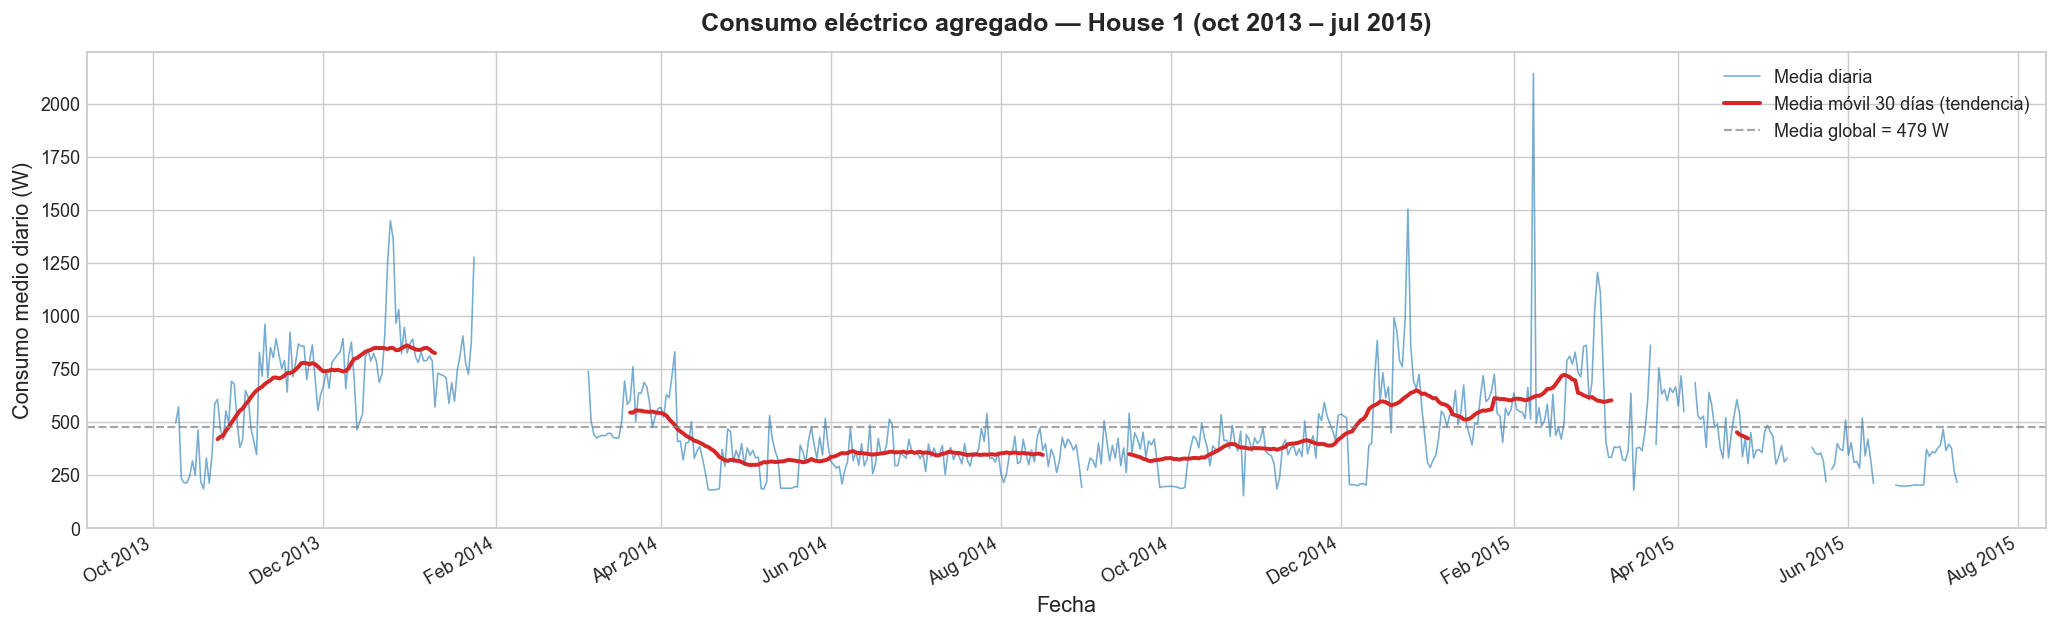

Figura exportada: 02_serie_temporal_completa.png


In [4]:
# ============================================================
# Figura 1: Serie temporal completa del consumo agregado
# Se usa la media diaria para una visualización legible a escala de 2 años
# y se superpone la media móvil de 30 días para destacar la tendencia
# ============================================================

# Remuestreo a resolución diaria para la vista de 2 años
consumo_diario = df_1min['Aggregate'].resample('D').mean()
media_movil_30 = consumo_diario.rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(consumo_diario.index, consumo_diario.values,
        color=COLOR_PRINC, lw=0.9, alpha=0.6, label='Media diaria')
ax.plot(media_movil_30.index, media_movil_30.values,
        color=COLOR_DEST, lw=2.2, label='Media móvil 30 días (tendencia)')
ax.axhline(consumo_diario.mean(), color='gray', lw=1.2,
           linestyle='--', alpha=0.7, label=f'Media global = {consumo_diario.mean():.0f} W')

ax.set_title('Consumo eléctrico agregado — House 1 (oct 2013 – jul 2015)', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo medio diario (W)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '02_serie_temporal_completa.png'), bbox_inches='tight')
plt.show()
print('Figura exportada: 02_serie_temporal_completa.png')

## 5. Patrón diario — consumo medio por hora <a id='5'></a>

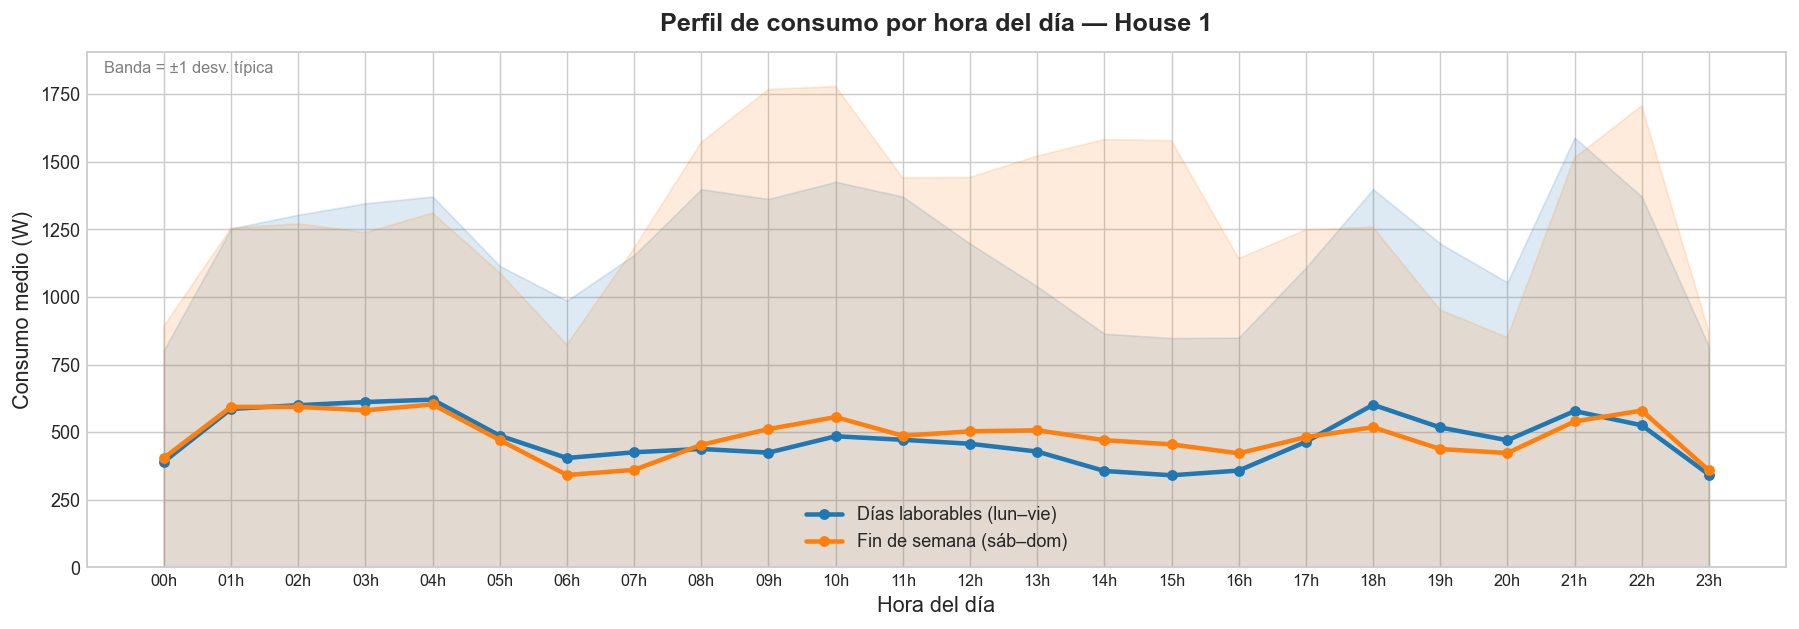

Figura exportada: 02_patron_diario_horas.png


In [5]:
# ============================================================
# Figura 2: Perfil de consumo medio por hora del día
# Se desglosa entre días laborables y fin de semana
# para revelar diferencias de comportamiento
# ============================================================

df_plot = df_1min[['Aggregate']].dropna().copy()
df_plot['hora']       = df_plot.index.hour
df_plot['es_finde']   = df_plot.index.dayofweek >= 5  # sábado=5, domingo=6

# Media y desviación típica por hora, separando laborable / fin de semana
perfil_lab   = df_plot[~df_plot['es_finde']].groupby('hora')['Aggregate'].agg(['mean', 'std'])
perfil_finde = df_plot[ df_plot['es_finde']].groupby('hora')['Aggregate'].agg(['mean', 'std'])

horas = np.arange(24)

fig, ax = plt.subplots(figsize=(14, 5))

for perfil, color, etiqueta in [
    (perfil_lab,   COLOR_PRINC, 'Días laborables (lun–vie)'),
    (perfil_finde, COLOR_SEC,   'Fin de semana (sáb–dom)'),
]:
    ax.plot(horas, perfil['mean'], color=color, lw=2.5, marker='o',
            markersize=5, label=etiqueta)
    ax.fill_between(
        horas,
        perfil['mean'] - perfil['std'],
        perfil['mean'] + perfil['std'],
        color=color, alpha=0.15
    )

ax.set_title('Perfil de consumo por hora del día — House 1', pad=12)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Consumo medio (W)')
ax.set_xticks(horas)
ax.set_xticklabels([f'{h:02d}h' for h in horas], fontsize=9)
ax.set_ylim(bottom=0)
ax.legend()
ax.annotate('Banda = ±1 desv. típica', xy=(0.01, 0.96),
            xycoords='axes fraction', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '02_patron_diario_horas.png'), bbox_inches='tight')
plt.show()
print('Figura exportada: 02_patron_diario_horas.png')

## 6. Patrón semanal — consumo medio por día de la semana <a id='6'></a>

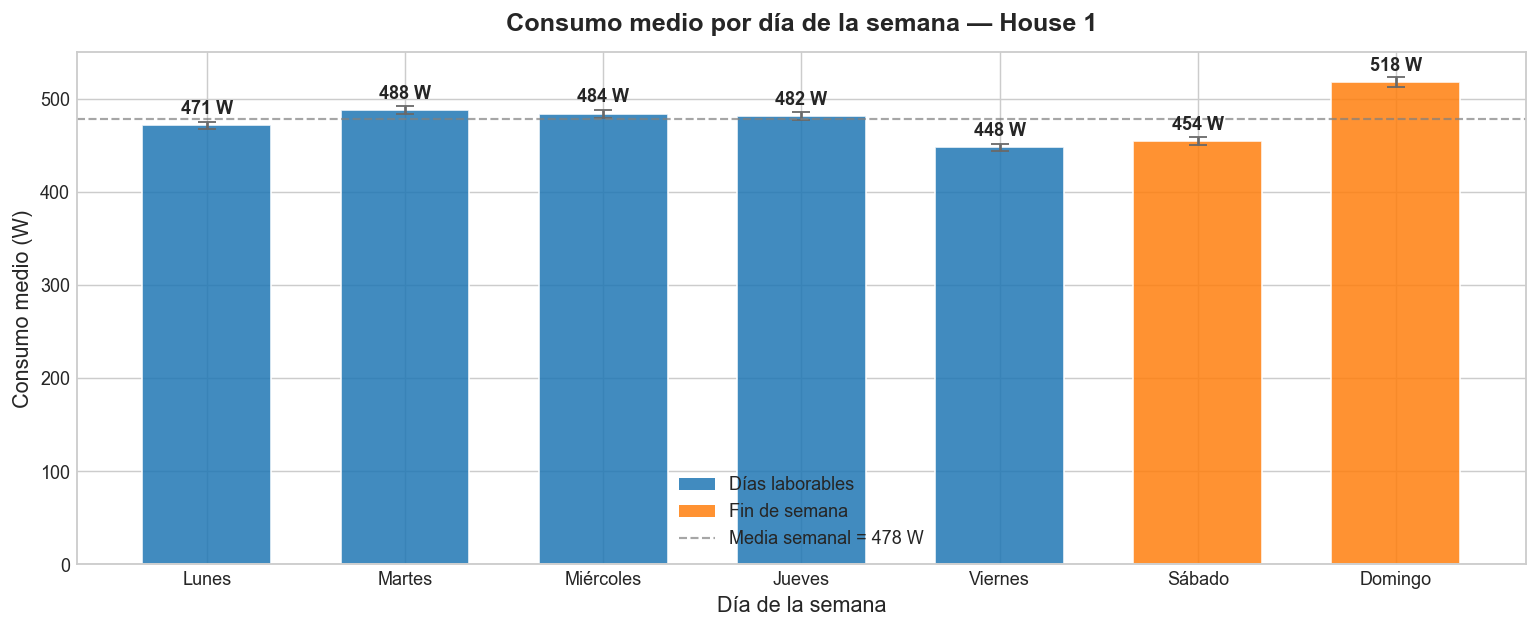

Figura exportada: 02_patron_semanal.png


In [6]:
# ============================================================
# Figura 3: Consumo medio por día de la semana (lunes a domingo)
# Se añade el intervalo de confianza al 95% (±1.96·SE)
# ============================================================

df_sem = df_1min[['Aggregate']].dropna().copy()
df_sem['dia_semana'] = df_sem.index.dayofweek  # 0=lunes … 6=domingo

stats_sem = df_sem.groupby('dia_semana')['Aggregate'].agg(
    media='mean', std='std', n='count'
)
# Intervalo de confianza al 95%
stats_sem['ic95'] = 1.96 * stats_sem['std'] / np.sqrt(stats_sem['n'])

colores_barras = [COLOR_PRINC if d < 5 else COLOR_SEC for d in range(7)]

fig, ax = plt.subplots(figsize=(12, 5))

barras = ax.bar(
    range(7),
    stats_sem['media'],
    color=colores_barras,
    alpha=0.85,
    edgecolor='white',
    width=0.65,
    yerr=stats_sem['ic95'],
    capsize=5,
    error_kw=dict(elinewidth=1.5, ecolor='dimgray')
)

# Etiquetas de valor encima de cada barra
for barra, valor in zip(barras, stats_sem['media']):
    ax.text(barra.get_x() + barra.get_width() / 2,
            valor + 8, f'{valor:.0f} W',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(stats_sem['media'].mean(), color='gray',
           linestyle='--', lw=1.2, alpha=0.7,
           label=f'Media semanal = {stats_sem["media"].mean():.0f} W')

ax.set_title('Consumo medio por día de la semana — House 1', pad=12)
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Consumo medio (W)')
ax.set_xticks(range(7))
ax.set_xticklabels(DIAS_SEMANA)
ax.set_ylim(bottom=0)
ax.legend()

from matplotlib.patches import Patch
leyenda_extra = [
    Patch(facecolor=COLOR_PRINC, alpha=0.85, label='Días laborables'),
    Patch(facecolor=COLOR_SEC,   alpha=0.85, label='Fin de semana'),
]
ax.legend(handles=leyenda_extra + ax.get_legend_handles_labels()[0],
          labels=['Días laborables', 'Fin de semana',
                  f'Media semanal = {stats_sem["media"].mean():.0f} W'])

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '02_patron_semanal.png'), bbox_inches='tight')
plt.show()
print('Figura exportada: 02_patron_semanal.png')

## 7. Estacionalidad anual — consumo medio por mes <a id='7'></a>

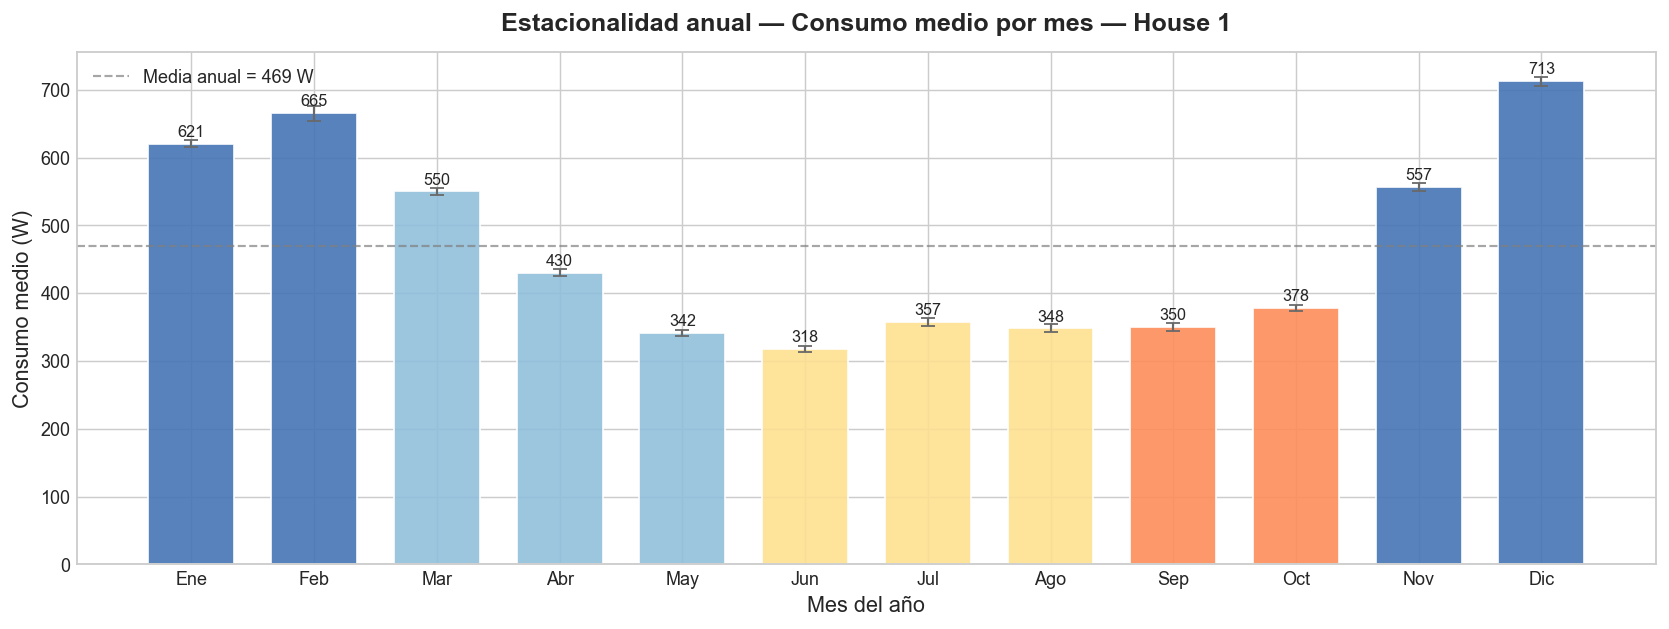

Figura exportada: 02_estacionalidad_mensual.png


In [7]:
# ============================================================
# Figura 4: Consumo medio por mes del año
# Se agrupan todos los registros disponibles por número de mes
# para capturar la estacionalidad independientemente del año
# ============================================================

df_mes = df_1min[['Aggregate']].dropna().copy()
df_mes['mes'] = df_mes.index.month  # 1=enero … 12=diciembre

stats_mes = df_mes.groupby('mes')['Aggregate'].agg(
    media='mean', std='std', n='count'
)
stats_mes['ic95'] = 1.96 * stats_mes['std'] / np.sqrt(stats_mes['n'])

# Paleta cálida en invierno / fría en verano (sugerencia visual de estación)
colores_mes = [
    '#4575b4', '#4575b4',  # ene, feb — invierno
    '#91bfdb', '#91bfdb', '#91bfdb',  # mar, abr, may — primavera
    '#fee090', '#fee090', '#fee090',  # jun, jul, ago — verano
    '#fc8d59', '#fc8d59',             # sep, oct — otoño
    '#4575b4', '#4575b4',             # nov, dic — invierno
]

fig, ax = plt.subplots(figsize=(13, 5))

barras = ax.bar(
    range(1, 13),
    stats_mes['media'],
    color=colores_mes,
    edgecolor='white',
    width=0.7,
    alpha=0.9,
    yerr=stats_mes['ic95'],
    capsize=4,
    error_kw=dict(elinewidth=1.2, ecolor='dimgray')
)

for barra, valor in zip(barras, stats_mes['media']):
    ax.text(barra.get_x() + barra.get_width() / 2,
            valor + 6, f'{valor:.0f}',
            ha='center', va='bottom', fontsize=9)

ax.axhline(stats_mes['media'].mean(), color='gray',
           linestyle='--', lw=1.2, alpha=0.7,
           label=f'Media anual = {stats_mes["media"].mean():.0f} W')

ax.set_title('Estacionalidad anual — Consumo medio por mes — House 1', pad=12)
ax.set_xlabel('Mes del año')
ax.set_ylabel('Consumo medio (W)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES)
ax.set_ylim(bottom=0)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '02_estacionalidad_mensual.png'), bbox_inches='tight')
plt.show()
print('Figura exportada: 02_estacionalidad_mensual.png')

## 8. Heatmap de semana típica <a id='8'></a>

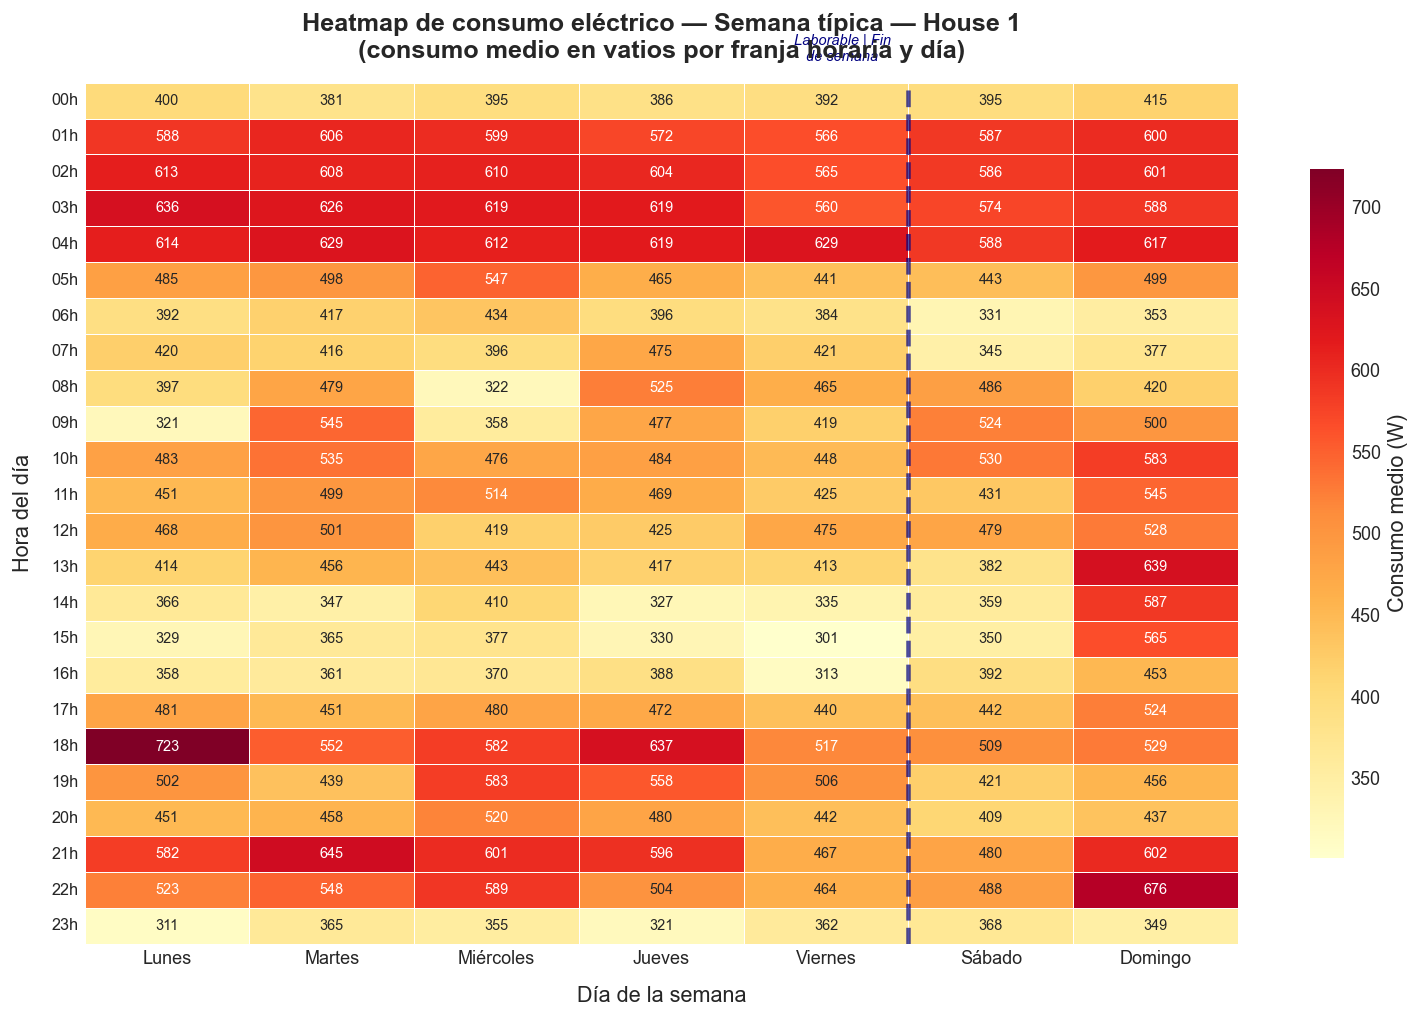

Figura exportada: 02_heatmap_semana_tipica.png


In [8]:
# ============================================================
# Figura 5: Heatmap hora × día de la semana
# Eje X = día de la semana (lunes→domingo)
# Eje Y = hora del día (0h→23h)
# Valor = consumo medio en vatios
# Esta visualización resume en una sola figura toda la variabilidad
# temporal que el modelo deberá capturar
# ============================================================

df_hm = df_1min[['Aggregate']].dropna().copy()
df_hm['hora']        = df_hm.index.hour
df_hm['dia_semana']  = df_hm.index.dayofweek  # 0=lunes … 6=domingo

# Tabla pivotante: filas=hora, columnas=día de la semana
pivot = df_hm.groupby(['hora', 'dia_semana'])['Aggregate'].mean().unstack()
pivot.columns = DIAS_SEMANA

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Consumo medio (W)', 'shrink': 0.8},
)

ax.set_title('Heatmap de consumo eléctrico — Semana típica — House 1\n'
             '(consumo medio en vatios por franja horaria y día)', pad=14)
ax.set_xlabel('Día de la semana', labelpad=10)
ax.set_ylabel('Hora del día', labelpad=10)
ax.set_yticklabels([f'{h:02d}h' for h in range(24)], rotation=0, fontsize=9)

# Línea vertical que separa laborables de fin de semana
ax.axvline(x=5, color='navy', lw=2.5, linestyle='--', alpha=0.7)
ax.text(4.6, -0.6, 'Laborable | Fin\nde semana',
        ha='center', fontsize=8, color='navy', style='italic')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '02_heatmap_semana_tipica.png'), bbox_inches='tight')
plt.show()
print('Figura exportada: 02_heatmap_semana_tipica.png')

## Resumen de figuras generadas

In [9]:
# ============================================================
# Verificación de que todas las figuras se han exportado
# ============================================================

figuras = [
    ('02_serie_temporal_completa.png',  'Serie temporal completa 2 años'),
    ('02_patron_diario_horas.png',      'Patrón diario por hora (lab. vs finde)'),
    ('02_patron_semanal.png',           'Patrón semanal por día'),
    ('02_estacionalidad_mensual.png',   'Estacionalidad mensual'),
    ('02_heatmap_semana_tipica.png',    'Heatmap semana típica'),
]

print('=== Figuras exportadas a resultados/figuras/ ===')
for nombre, descripcion in figuras:
    existe = os.path.exists(os.path.join(RUTA_FIGS, nombre))
    estado = 'OK' if existe else 'FALTA'
    print(f'  [{estado:5s}]  {nombre:<45s}  {descripcion}')

print('\n=== CSV exportados a resultados/metricas/ ===')
csv_path = os.path.join(RUTA_MET, '02_estadisticas_house1_1min.csv')
print(f'  [{"OK" if os.path.exists(csv_path) else "FALTA":5s}]  02_estadisticas_house1_1min.csv')

print('\n=== Notebook 02 completado ===')
print('Próximo paso: Notebook 03 — Limpieza de datos')
print('  - Tratamiento de Issues=1 (especialmente House3: 5.84%)')
print('  - Recorte de outliers severos (House3 máx: 65,836 W)')
print('  - Imputación de NaN introducidos por el remuestreo')
print('  - Guardado de datos limpios en datos/processed/')

=== Figuras exportadas a resultados/figuras/ ===
  [OK   ]  02_serie_temporal_completa.png                 Serie temporal completa 2 años
  [OK   ]  02_patron_diario_horas.png                     Patrón diario por hora (lab. vs finde)
  [OK   ]  02_patron_semanal.png                          Patrón semanal por día
  [OK   ]  02_estacionalidad_mensual.png                  Estacionalidad mensual
  [OK   ]  02_heatmap_semana_tipica.png                   Heatmap semana típica

=== CSV exportados a resultados/metricas/ ===
  [OK   ]  02_estadisticas_house1_1min.csv

=== Notebook 02 completado ===
Próximo paso: Notebook 03 — Limpieza de datos
  - Tratamiento de Issues=1 (especialmente House3: 5.84%)
  - Recorte de outliers severos (House3 máx: 65,836 W)
  - Imputación de NaN introducidos por el remuestreo
  - Guardado de datos limpios en datos/processed/
